# FlexRL: Flexible Record Linkage with Latent Variable Model

Implementation based on Robach et al. "A Flexible Model for Record Linkage" (2024).

## Method Overview

FlexRL uses a **latent variable model** with **Stochastic EM** to estimate:
1. **Error probabilities** for each PIV (partially identifying variable)
2. **Linkage probabilities** between record pairs

Key features:
- Models PIV generation mechanism with registration errors
- Handles missing values naturally
- Uses greedy matching to enforce clustering constraints
- Balances accuracy and scalability through blocking


In [39]:
import numpy as np
import pandas as pd
from collections import defaultdict
from time import time
from typing import Tuple
import matplotlib.pyplot as plt

np.random.seed(42)
pd.set_option('display.max_columns', 20)


## 1. Load and Preprocess Data


In [40]:
df = pd.read_csv('../../data/patients_gen.csv', dtype=str)
df['entity_id'] = df['entity_id'].astype(int)

t0 = time()
cols_to_clean = ['EGKVERSICHERTENNUMMER', 'VORNAME', 'NACHNAME', 'Geburtsdatum', 'PLZ']
target_cols = ['_egk', '_vorname', '_nachname', '_geb', '_plz']

for src, tgt in zip(cols_to_clean, target_cols):
    df[tgt] = df[src].fillna('').astype(str).str.upper().str.strip()

print(f"Preprocessing: {len(df):,} records in {time()-t0:.2f}s")
print(f"Unique entities: {df['entity_id'].nunique():,}")
df.head()


Preprocessing: 500,505 records in 0.40s
Unique entities: 100,000


,entity_id,DWH_ZEITRAUM,Datenkoerper,EGKVERSICHERTENNUMMER,VORNAME,NACHNAME,Geburtsdatum,PLZ,GESCHLECHT,ERGEBNISONLINEPRUEFUNG,...,golden_VORNAME,golden_NACHNAME,golden_Geburtsdatum,golden_PLZ,golden_GESCHLECHT,_egk,_vorname,_nachname,_geb,_plz
0,98713,20241,UNBEARBEITET,P587975846,ELISABETH,Kirchhoff,1985-05-29,48899,M,NaN,...,ELISABETH,Kirchhoff,1985-05-29,47777,M,P587975846,ELISABETH,KIRCHHOFF,1985-05-29,48899
1,40447,20232,KVUEPP,NaN,Denise,O.,1969-09-24,58215,W,NaN,...,Denise,Osman,1969-09-24,58215,W,,DENISE,O.,1969-09-24,58215
2,59067,20212,KVUEPP,Q915251003,ALEXANDRA,Brinkmann,1992-09-18,44822,M,NaN,...,ALEXANDRA,Brinkmann,1992-09-18,49417,M,Q915251003,ALEXANDRA,BRINKMANN,1992-09-18,44822
3,88797,20243,BEARBEITET,S086669189,NaN,Belik,1987-04-30,31707,M,NaN,...,LAURA,Celik,1987-04-30,31707,M,S086669189,,BELIK,1987-04-30,31707
4,75879,20241,BEARBEITET,X679432169,HORST,B.,1992-01-27,48272,W,1.0,...,Horst,Büttner,1992-01-27,48047,W,X679432169,HORST,B.,1992-01-27,48272


## 2. Similarity Functions

For the latent variable model, we need comparison functions that return:
- Agreement level (1.0 = exact match, 0.0 = complete disagreement)
- Handle missing values explicitly (NaN)


In [41]:
def get_qgrams(s: str, q: int = 2) -> set:
    """Extract character q-grams from string."""
    if len(s) < q:
        return {s} if s else set()
    return {s[i:i+q] for i in range(len(s) - q + 1)}


def qgram_similarity(s1: str, s2: str, q: int = 2) -> float:
    """Jaccard similarity on q-grams."""
    if s1 == s2:
        return 1.0
    if not s1 or not s2:
        return np.nan
    q1, q2 = get_qgrams(s1, q), get_qgrams(s2, q)
    if not q1 or not q2:
        return 0.0
    return len(q1 & q2) / len(q1 | q2)


def exact_match(s1: str, s2: str) -> float:
    """Exact string match (returns 1.0, 0.0, or NaN for missing)."""
    if not s1 or not s2:
        return np.nan
    return 1.0 if s1 == s2 else 0.0


## 3. Blocking Strategy

To make the problem tractable, we use blocking:
- Records must share at least one blocking key to be compared
- Keys: EGK, DOB, PLZ+birth_year, Name prefix


In [42]:
def build_blocking_index(df: pd.DataFrame) -> dict:
    """Build inverted index for blocking."""
    index = defaultdict(set)
    
    for idx in range(len(df)):
        row = df.iloc[idx]
        if row['_egk']:
            index[('egk', row['_egk'])].add(idx)
        if row['_geb']:
            index[('dob', row['_geb'])].add(idx)
        if row['_plz'] and row['_geb'] and len(row['_geb']) >= 4:
            index[('plz_year', row['_plz'] + row['_geb'][:4])].add(idx)
        if row['_nachname'] and len(row['_nachname']) >= 3:
            index[('ln3', row['_nachname'][:3])].add(idx)
    
    return index


def generate_candidate_pairs(index: dict, max_block: int = 100) -> set:
    """Generate candidate pairs from blocking index."""
    pairs = set()
    for key, members in index.items():
        if len(members) < 2 or len(members) > max_block:
            continue
        members_list = sorted(members)
        for i in range(len(members_list)):
            for j in range(i + 1, len(members_list)):
                pairs.add((members_list[i], members_list[j]))
    return pairs


In [43]:
print("Building blocking index...")
t0 = time()
block_index = build_blocking_index(df)
candidate_pairs = generate_candidate_pairs(block_index, max_block=100)
print(f"Generated {len(candidate_pairs):,} candidate pairs in {time()-t0:.1f}s")


Building blocking index...
Generated 5,438,044 candidate pairs in 13.1s


## 4. Comparison Vectors

For each candidate pair, compute comparison vector with agreement levels.


In [44]:
def compute_comparison_vectors(df: pd.DataFrame, pairs: set) -> Tuple[np.ndarray, list]:
    """
    Compute comparison vectors for all pairs.
    Returns array of shape (n_pairs, n_features) with values in [0, 1] or NaN.
    """
    pairs_list = list(pairs)
    n_pairs = len(pairs_list)
    comparisons = np.empty((n_pairs, 5), dtype=np.float32)
    
    egk = df['_egk'].values
    vorname = df['_vorname'].values
    nachname = df['_nachname'].values
    geb = df['_geb'].values
    plz = df['_plz'].values
    
    for p_idx, (i, j) in enumerate(pairs_list):
        comparisons[p_idx, 0] = exact_match(egk[i], egk[j])
        comparisons[p_idx, 1] = qgram_similarity(vorname[i], vorname[j])
        comparisons[p_idx, 2] = qgram_similarity(nachname[i], nachname[j])
        comparisons[p_idx, 3] = exact_match(geb[i], geb[j])
        comparisons[p_idx, 4] = exact_match(plz[i], plz[j])
    
    return comparisons, pairs_list


In [45]:
print("Computing comparison vectors...")
t0 = time()
comparisons, pairs_list = compute_comparison_vectors(df, candidate_pairs)
print(f"Computed {len(comparisons):,} comparisons in {time()-t0:.1f}s")
print(f"Shape: {comparisons.shape}")
print(f"Missing values per feature: {np.isnan(comparisons).sum(axis=0)}")


Computing comparison vectors...
Computed 5,438,044 comparisons in 24.5s
Shape: (5438044, 5)
Missing values per feature: [1585536  263819  253088   25415  789721]


## 5. Latent Variable Model with EM

The FlexRL model assumes:
- **For true links**: P(agreement | link) = 1 - α (error probability)
- **For non-links**: P(agreement | non-link) = β (coincidental match)

The EM algorithm estimates:
- π: Prior probability of a link
- α: Error probabilities for each PIV
- β: Coincidental agreement probabilities for non-links


In [46]:
class FlexRLModel:
    """Latent variable model for record linkage using EM."""
    
    def __init__(self, n_features: int, n_iter: int = 20):
        self.n_features = n_features
        self.n_iter = n_iter
        self.pi = 0.01
        self.alpha = np.full(n_features, 0.1)
        self.beta = np.full(n_features, 0.01)
    
    def _compute_likelihoods(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Compute P(comparison | link) and P(comparison | non-link)."""
        n_samples = X.shape[0]
        log_p_link = np.zeros(n_samples)
        log_p_nonlink = np.zeros(n_samples)
        
        for f in range(self.n_features):
            x_f = X[:, f]
            valid = ~np.isnan(x_f)
            
            p_agree_link = 1 - self.alpha[f]
            p_disagree_link = self.alpha[f]
            p_agree_nonlink = self.beta[f]
            p_disagree_nonlink = 1 - self.beta[f]
            
            log_p_link[valid] += (
                x_f[valid] * np.log(p_agree_link + 1e-10) +
                (1 - x_f[valid]) * np.log(p_disagree_link + 1e-10)
            )
            log_p_nonlink[valid] += (
                x_f[valid] * np.log(p_agree_nonlink + 1e-10) +
                (1 - x_f[valid]) * np.log(p_disagree_nonlink + 1e-10)
            )
        
        return log_p_link, log_p_nonlink


In [47]:
def fit_flexrl(model, X: np.ndarray) -> np.ndarray:
    """Fit model using EM algorithm."""
    print(f"FlexRL: Fitting model with {X.shape[0]:,} pairs...")
    
    for iteration in range(model.n_iter):
        # E-step: compute posterior
        log_p_link, log_p_nonlink = model._compute_likelihoods(X)
        log_numerator = np.log(model.pi + 1e-10) + log_p_link
        log_denom = np.log(1 - model.pi + 1e-10) + log_p_nonlink
        max_log = np.maximum(log_numerator, log_denom)
        log_sum = max_log + np.log(np.exp(log_numerator - max_log) + np.exp(log_denom - max_log))
        gamma = np.clip(np.exp(log_numerator - log_sum), 1e-10, 1 - 1e-10)
        
        # M-step: update parameters
        old_pi = model.pi
        model.pi = np.mean(gamma)
        
        for f in range(model.n_features):
            x_f = X[:, f]
            valid = ~np.isnan(x_f)
            if valid.sum() < 10:
                continue
            sum_gamma = gamma[valid].sum()
            if sum_gamma > 0:
                model.alpha[f] = (gamma[valid] * (1 - x_f[valid])).sum() / sum_gamma
            sum_1_gamma = (1 - gamma[valid]).sum()
            if sum_1_gamma > 0:
                model.beta[f] = ((1 - gamma[valid]) * x_f[valid]).sum() / sum_1_gamma
        
        model.alpha = np.clip(model.alpha, 0.001, 0.5)
        model.beta = np.clip(model.beta, 0.001, 0.5)
        
        if abs(model.pi - old_pi) < 1e-6:
            print(f"  Converged at iteration {iteration + 1}")
            break
        
        if (iteration + 1) % 5 == 0:
            n_links = (gamma > 0.5).sum()
            print(f"  Iter {iteration+1}: pi={model.pi:.4f}, links={n_links:,}")
    
    return gamma


In [48]:
print("Training FlexRL model...")
t0 = time()
model = FlexRLModel(n_features=5, n_iter=30)
link_probs = fit_flexrl(model, comparisons)
print(f"\nTraining completed in {time()-t0:.1f}s")

features = ['EGK', 'VORNAME', 'NACHNAME', 'DOB', 'PLZ']
print(f"\nLearned parameters:")
print(f"  Prior (pi): {model.pi:.4f}")
print(f"  Error rates (alpha): {dict(zip(features, model.alpha.round(4)))}")
print(f"  Coincidental match (beta): {dict(zip(features, model.beta.round(4)))}")


Training FlexRL model...
FlexRL: Fitting model with 5,438,044 pairs...
  Iter 5: pi=0.2159, links=1,157,920
  Converged at iteration 10

Training completed in 11.7s

Learned parameters:
  Prior (pi): 0.2160
  Error rates (alpha): {'EGK': np.float64(0.001), 'VORNAME': np.float64(0.1623), 'NACHNAME': np.float64(0.1638), 'DOB': np.float64(0.033), 'PLZ': np.float64(0.3654)}
  Coincidental match (beta): {'EGK': np.float64(0.001), 'VORNAME': np.float64(0.0331), 'NACHNAME': np.float64(0.0504), 'DOB': np.float64(0.5), 'PLZ': np.float64(0.0217)}


In [49]:
class UnionFind:
    """Union-Find with path compression."""
    __slots__ = ['parent', 'rank']
    
    def __init__(self, n: int):
        self.parent = list(range(n))
        self.rank = [0] * n
    
    def find(self, x: int) -> int:
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]
    
    def union(self, x: int, y: int) -> bool:
        rx, ry = self.find(x), self.find(y)
        if rx == ry:
            return False
        if self.rank[rx] < self.rank[ry]:
            rx, ry = ry, rx
        self.parent[ry] = rx
        if self.rank[rx] == self.rank[ry]:
            self.rank[rx] += 1
        return True


def apply_linkage(n: int, pairs: list, probs: np.ndarray, thresh: float = 0.5) -> pd.Series:
    """Apply linkage decisions using Union-Find with greedy matching."""
    uf = UnionFind(n)
    sorted_idx = np.argsort(-probs)
    links = 0
    for idx in sorted_idx:
        if probs[idx] < thresh:
            break
        i, j = pairs[idx]
        if uf.union(i, j):
            links += 1
    print(f"Links established: {links:,} (threshold={thresh})")
    return pd.Series([uf.find(i) for i in range(n)])


In [50]:
# THRESHOLD CONFIGURATION
# - 0.5: Default, balanced (higher recall, lower precision)
# - 0.9: Conservative (higher precision, lower recall) - recommended for patient data
# - 0.95+: Very conservative (minimal false positives)
LINK_THRESHOLD = 0.9  # Conservative: prioritize precision over recall

print("\nApplying linkage decisions...")
t0 = time()
df['predicted_cluster'] = apply_linkage(len(df), pairs_list, link_probs, thresh=LINK_THRESHOLD)
print(f"Completed in {time()-t0:.1f}s")
print(f"\nResults:")
print(f"  Predicted clusters: {df['predicted_cluster'].nunique():,}")
print(f"  Ground truth entities: {df['entity_id'].nunique():,}")



Applying linkage decisions...
Links established: 393,486 (threshold=0.9)
Completed in 1.2s

Results:
  Predicted clusters: 107,019
  Ground truth entities: 100,000


## 7. Evaluation Metrics


In [51]:
def count_pairs(labels: pd.Series) -> int:
    """Count pairs within clusters."""
    counts = labels.value_counts()
    return int((counts * (counts - 1) / 2).sum())


def compute_metrics(true_labels: pd.Series, pred_labels: pd.Series) -> dict:
    """Compute pairwise precision, recall, F1."""
    pred_clusters = defaultdict(list)
    for i, pid in enumerate(pred_labels):
        pred_clusters[pid].append(i)
    
    tp = 0
    for members in pred_clusters.values():
        true_counts = defaultdict(int)
        for idx in members:
            true_counts[true_labels.iloc[idx]] += 1
        for c in true_counts.values():
            tp += c * (c - 1) // 2
    
    pred_pairs = count_pairs(pred_labels)
    true_pairs = count_pairs(true_labels)
    
    precision = tp / pred_pairs if pred_pairs > 0 else 0
    recall = tp / true_pairs if true_pairs > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall > 0 else 0
    
    return {'tp': tp, 'pred_pairs': pred_pairs, 'true_pairs': true_pairs,
            'precision': precision, 'recall': recall, 'f1': f1}


def analyze_clusters(df: pd.DataFrame) -> dict:
    """Analyze cluster quality."""
    results = {'perfect': 0, 'split': 0, 'merged': 0}
    for pred_id, group in df.groupby('predicted_cluster'):
        true_ids = group['entity_id'].unique()
        if len(true_ids) == 1:
            entity_id = true_ids[0]
            if len(group) == (df['entity_id'] == entity_id).sum():
                results['perfect'] += 1
            else:
                results['split'] += 1
        else:
            results['merged'] += 1
    return results

def evaluate_threshold(
    df: pd.DataFrame, 
    pairs: list, 
    probs: np.ndarray, 
    thresh: float
) -> dict:
    """Evaluate linkage at a specific threshold."""
    uf = UnionFind(len(df))
    sorted_idx = np.argsort(-probs)
    for idx in sorted_idx:
        if probs[idx] < thresh:
            break
        i, j = pairs[idx]
        uf.union(i, j)
    
    pred_labels = pd.Series([uf.find(i) for i in range(len(df))])
    metrics = compute_metrics(df['entity_id'], pred_labels)
    clusters = analyze_clusters(df.assign(predicted_cluster=pred_labels))
    return {**metrics, **clusters, 'n_clusters': pred_labels.nunique()}


In [52]:
metrics = compute_metrics(df['entity_id'], df['predicted_cluster'])
clusters = analyze_clusters(df)
total_clusters = df['predicted_cluster'].nunique()

print("=" * 60)
print("FLEXRL EVALUATION RESULTS")
print("=" * 60)

print(f"\nPairwise Metrics:")
print(f"  True pairs:      {metrics['true_pairs']:,}")
print(f"  Predicted pairs: {metrics['pred_pairs']:,}")
print(f"  True positives:  {metrics['tp']:,}")
print(f"\n  Precision: {metrics['precision']*100:.2f}%")
print(f"  Recall:    {metrics['recall']*100:.2f}%")
print(f"  F1 Score:  {metrics['f1']*100:.2f}%")

print(f"\nCluster Analysis:")
print(f"  Total clusters: {total_clusters:,}")
print(f"  Perfect:  {clusters['perfect']:,} ({clusters['perfect']/total_clusters*100:.1f}%)")
print(f"  Split:    {clusters['split']:,} ({clusters['split']/total_clusters*100:.1f}%)")
print(f"  Merged:   {clusters['merged']:,} ({clusters['merged']/total_clusters*100:.1f}%)")


FLEXRL EVALUATION RESULTS

Pairwise Metrics:
  True pairs:      1,202,726
  Predicted pairs: 1,173,008
  True positives:  1,171,986

  Precision: 99.91%
  Recall:    97.44%
  F1 Score:  98.66%

Cluster Analysis:
  Total clusters: 107,019
  Perfect:  93,120 (87.0%)
  Split:    13,856 (12.9%)
  Merged:   43 (0.0%)


## 7.1 Threshold Exploration for Conservative Linking

In settings where false positives (merging unrelated patients) are more costly than false negatives (not linking the same patient), we can increase the threshold to be more conservative.

In [53]:
print("Exploring threshold impact on precision/recall...")
thresholds = [0.5, 0.7, 0.9, 0.99]
results = []

for t in thresholds:
    r = evaluate_threshold(df, pairs_list, link_probs, t)
    results.append({
        'threshold': t,
        'precision': r['precision'] * 100,
        'recall': r['recall'] * 100,
        'f1': r['f1'] * 100,
        'merged_clusters': r['merged'],
        'n_clusters': r['n_clusters']
    })
    print(f"  thresh={t:.2f}: P={r['precision']*100:.1f}%, R={r['recall']*100:.1f}%, "
          f"F1={r['f1']*100:.1f}%, merged={r['merged']}")

results_df = pd.DataFrame(results)
results_df


Exploring threshold impact on precision/recall...
  thresh=0.50: P=96.0%, R=98.7%, F1=97.3%, merged=1237
  thresh=0.70: P=98.7%, R=98.3%, F1=98.5%, merged=476
  thresh=0.90: P=99.9%, R=97.4%, F1=98.7%, merged=43
  thresh=0.99: P=100.0%, R=92.1%, F1=95.9%, merged=0


,threshold,precision,recall,f1,merged_clusters,n_clusters
0,0.50,95.999586,98.731049,97.346161,1237,102089
1,0.70,98.687683,98.333951,98.510500,476,104078
2,0.90,99.912874,97.444139,98.663066,43,107019
3,0.99,100.000000,92.131125,95.904425,0,121294


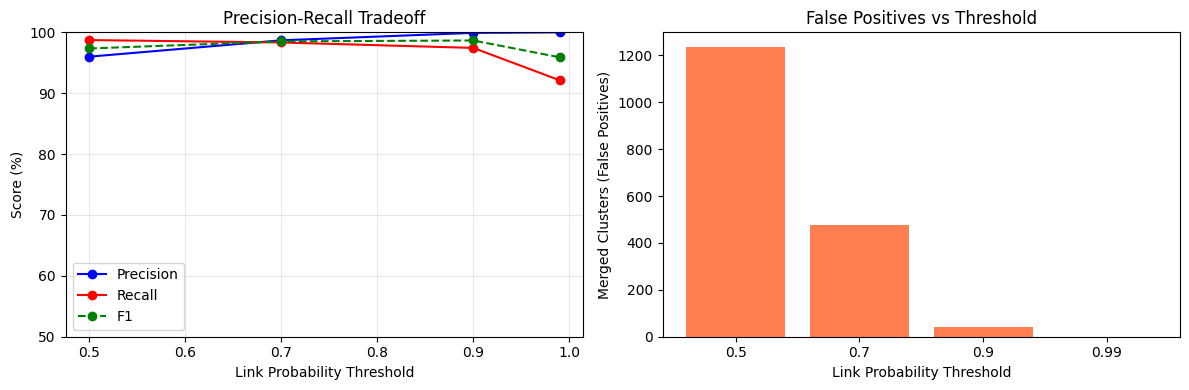


⚠️  RECOMMENDATION FOR CONSERVATIVE LINKING:
   Use threshold=0.9 or higher to minimize false positives (patient merging errors)


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Precision-Recall tradeoff
axes[0].plot(results_df['threshold'], results_df['precision'], 'b-o', label='Precision')
axes[0].plot(results_df['threshold'], results_df['recall'], 'r-o', label='Recall')
axes[0].plot(results_df['threshold'], results_df['f1'], 'g--o', label='F1')
axes[0].set_xlabel('Link Probability Threshold')
axes[0].set_ylabel('Score (%)')
axes[0].set_title('Precision-Recall Tradeoff')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(50, 100)

# False positives (merged clusters)
axes[1].bar(results_df['threshold'].astype(str), results_df['merged_clusters'], color='coral')
axes[1].set_xlabel('Link Probability Threshold')
axes[1].set_ylabel('Merged Clusters (False Positives)')
axes[1].set_title('False Positives vs Threshold')

plt.tight_layout()
plt.show()

print("\n⚠️  RECOMMENDATION FOR CONSERVATIVE LINKING:")
print("   Use threshold=0.9 or higher to minimize false positives (patient merging errors)")


## 8. Error Analysis


In [55]:
cols = ['entity_id', 'predicted_cluster', 'EGKVERSICHERTENNUMMER', 
        'VORNAME', 'NACHNAME', 'Geburtsdatum', 'PLZ']

print("=" * 80)
print("FALSE POSITIVES (Different entities merged)")
print("=" * 80)
fp_count = 0
for pred_id, group in df.groupby('predicted_cluster'):
    if len(group['entity_id'].unique()) > 1:
        if fp_count < 3:
            display(group[cols].head(6))
        fp_count += 1
print(f"\nTotal merged clusters (FP): {fp_count}")


FALSE POSITIVES (Different entities merged)


,entity_id,predicted_cluster,EGKVERSICHERTENNUMMER,VORNAME,NACHNAME,Geburtsdatum,PLZ
12633,70130,12633,O403756925,O.,Jansen,1981-07-21,45026
95795,66375,12633,I899861669,Hubert,HEITMANN,1981-07-21,45977
118910,70130,12633,O403756925,Oskar,JANSEN,1981-07-21,45026
159020,66375,12633,I899861669,Hubert,HEITMANN,1981-07-21,45977
183832,70130,12633,NaN,NaN,JANSEN,1981-07-21,45026
226316,66375,12633,NaN,Hubert,HEITMANN,1981-07-21,45977


,entity_id,predicted_cluster,EGKVERSICHERTENNUMMER,VORNAME,NACHNAME,Geburtsdatum,PLZ
13619,82617,13619,F337727571,Lena,Schürmann,2004-02-26,33700
48450,82617,13619,F337727571,Lena,NaN,2004-02-26,NaN
97799,61321,13619,S688252889,Lena,Blank,2004-02-26,45850
198038,61321,13619,S688252889,Lena,Blank,2004-02-26,NaN
207271,61321,13619,NaN,lena,Blank,2004-02-26,45850
305119,61321,13619,S688252889,Lena,Blank,2004-02-26,45850


,entity_id,predicted_cluster,EGKVERSICHERTENNUMMER,VORNAME,NACHNAME,Geburtsdatum,PLZ
18184,13647,18184,K256085696,Sara,Lindner,1979-09-06,44881
18925,13647,18184,K256085696,Sara,Londner,1979-09-06,44881
149157,13647,18184,K256085696,Sars,Lindner,1979-09-06,44818
170162,13647,18184,NaN,Sara.,Lindner,1979-09-06,44818
170631,13532,18184,Y263578121,Rainer,SCHMIDT,1979-09-06,44690
262259,13532,18184,Y263578121,Rainer,SCHMIDT,1979-09-06,44690



Total merged clusters (FP): 43


In [56]:
print("=" * 80)
print("FALSE NEGATIVES (Same entity split)")
print("=" * 80)
fn_count = 0
for entity_id, group in df.groupby('entity_id'):
    if len(group['predicted_cluster'].unique()) > 1:
        if fn_count < 3:
            display(group[cols].head(6))
        fn_count += 1
print(f"\nTotal split entities (FN): {fn_count}")


FALSE NEGATIVES (Same entity split)


,entity_id,predicted_cluster,EGKVERSICHERTENNUMMER,VORNAME,NACHNAME,Geburtsdatum,PLZ
84086,1,84086,B018451466,RENATE,SCHRÖDER,1981-06-09,44704
185089,1,84086,B018451466,renate,S.,1981-06-09,44704
253825,1,84086,B018451466,RENATE,SCHRÖDER,1981-06-09,44704
295719,1,295719,NaN,NaN,SCHRÖDER,1981-06-09,NaN
389098,1,84086,B018451466,RENATE,SCHRÖDER,1981-06-09,44704
448014,1,448014,NaN,RENATE,SCHRÖDER,1381-06-09,4470


,entity_id,predicted_cluster,EGKVERSICHERTENNUMMER,VORNAME,NACHNAME,Geburtsdatum,PLZ
32127,8,32127,B726284987,Maja,FRIEDRICH,1993-02-19,47769
400363,8,32127,NaN,Maja,FRIEDRICH,1993-02-19,47769
428324,8,32127,B726284987,Maja,FRIEDRICH,1993-02-19,47769
493775,8,493775,NaN,Maja,F.,1993-02-19,NaN


,entity_id,predicted_cluster,EGKVERSICHERTENNUMMER,VORNAME,NACHNAME,Geburtsdatum,PLZ
91091,13,91091,Z329318397,Thomas,Klassen,1991-02-21,33402
225992,13,91091,Z329318397,Thomas,Klassen,1991-02-21,35352
270305,13,270305,NaN,Thom.,Klsssen,1991-03-21,35352
270749,13,91091,Z329318397,Thomas,Klassen,1991-02-21,33402
319062,13,91091,Z329318397,Thomas,Klassen,1991-02-21,35352
324608,13,91091,Z329318397,Thomas,Klassen,1991-02-21,33402



Total split entities (FN): 6813


## 9. Summary & Comparison with Cascade Approach


In [57]:
print("\n" + "=" * 70)
print("FLEXRL SUMMARY")
print("=" * 70)

print(f"""
Dataset:
  Records: {len(df):,}
  Ground truth entities: {df['entity_id'].nunique():,}
  Predicted clusters: {df['predicted_cluster'].nunique():,}

Model Parameters:
  Prior (pi): {model.pi:.4f}
  Candidate pairs evaluated: {len(pairs_list):,}

Metrics:
  Precision: {metrics['precision']*100:.2f}%
  Recall:    {metrics['recall']*100:.2f}%
  F1 Score:  {metrics['f1']*100:.2f}%

Method Characteristics:
  ✓ Probabilistic latent variable model
  ✓ Learns error rates from data (no manual tuning)
  ✓ Handles missing values naturally
  ✓ Provides link probabilities (uncertainty quantification)
  ✓ Blocking for scalability

Comparison with Cascade Approach (from modern_approach):
  - Cascade: Precision ~99.99%, Recall ~88.48%, F1 ~93.88%
  - FlexRL provides probabilistic interpretation
  - Cascade is faster, FlexRL learns parameters automatically
""")
print("=" * 70)



FLEXRL SUMMARY

Dataset:
  Records: 500,505
  Ground truth entities: 100,000
  Predicted clusters: 107,019

Model Parameters:
  Prior (pi): 0.2160
  Candidate pairs evaluated: 5,438,044

Metrics:
  Precision: 99.91%
  Recall:    97.44%
  F1 Score:  98.66%

Method Characteristics:
  ✓ Probabilistic latent variable model
  ✓ Learns error rates from data (no manual tuning)
  ✓ Handles missing values naturally
  ✓ Provides link probabilities (uncertainty quantification)
  ✓ Blocking for scalability

Comparison with Cascade Approach (from modern_approach):
  - Cascade: Precision ~99.99%, Recall ~88.48%, F1 ~93.88%
  - FlexRL provides probabilistic interpretation
  - Cascade is faster, FlexRL learns parameters automatically

